In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

In [3]:
!pip install requests

In [4]:
from google.colab import files
uploaded = files.upload()

Saving ipl_dataset_full.csv to ipl_dataset_full.csv


In [9]:
import pandas as pd

After installation, you can import and use the library in your notebook.

In [10]:
ipl = pd.read_csv('ipl_dataset_full.csv')
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-11,Wankhede Stadium,Royal Challengers Bangalore,Mumbai Indians,SC Ganguly,Z Khan,1,0,0.2,2,0,0,0,153
1,1,2008-04-11,Wankhede Stadium,Royal Challengers Bangalore,Mumbai Indians,SR Tendulkar,M Ntini,2,0,0.3,4,0,0,0,153
2,1,2008-04-11,Wankhede Stadium,Royal Challengers Bangalore,Mumbai Indians,V Sehwag,SK Warne,3,0,0.5,6,0,0,0,153
3,1,2008-04-11,Wankhede Stadium,Royal Challengers Bangalore,Mumbai Indians,MS Dhoni,SL Malinga,4,0,0.7,8,0,0,0,153
4,1,2008-04-11,Wankhede Stadium,Royal Challengers Bangalore,Mumbai Indians,YK Pathan,A Kumble,5,0,0.8,5,0,0,0,153


In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

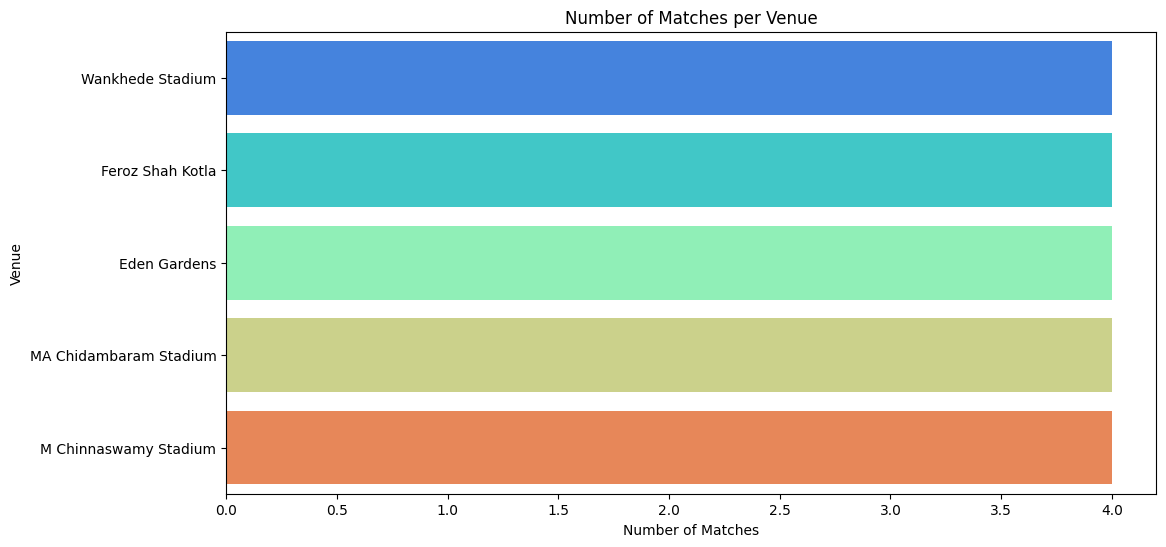

In [12]:
data = ipl.copy()
matches_per_venue = data[['mid', 'venue']].drop_duplicates()
matches_count = matches_per_venue['venue'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=matches_count.values, y=matches_count.index, palette="rainbow")
plt.title('Number of Matches per Venue')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.show()

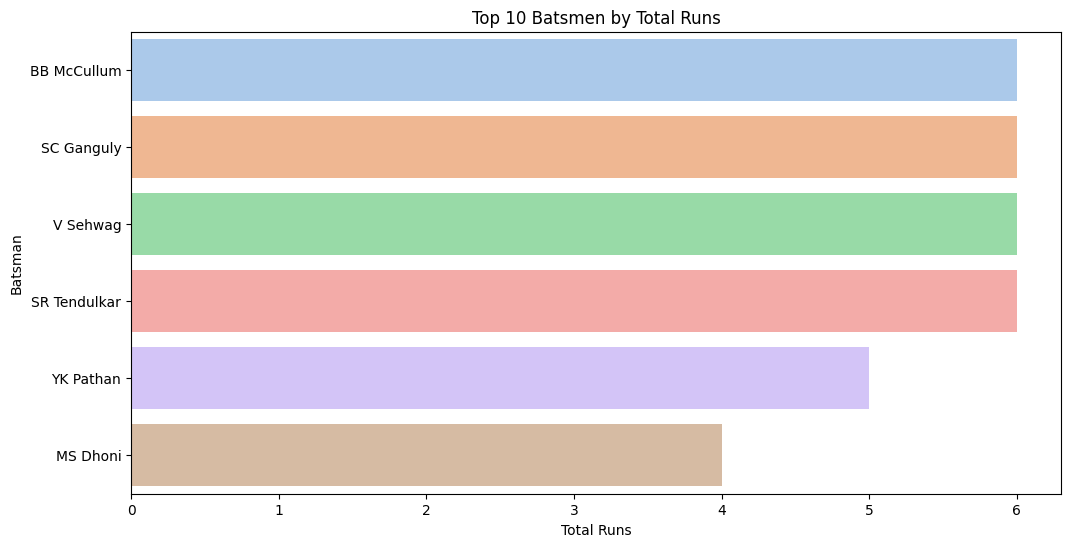

In [13]:
runs_by_batsman = data.groupby('batsman')['runs'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=runs_by_batsman.values, y=runs_by_batsman.index,palette="pastel")
plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.show()

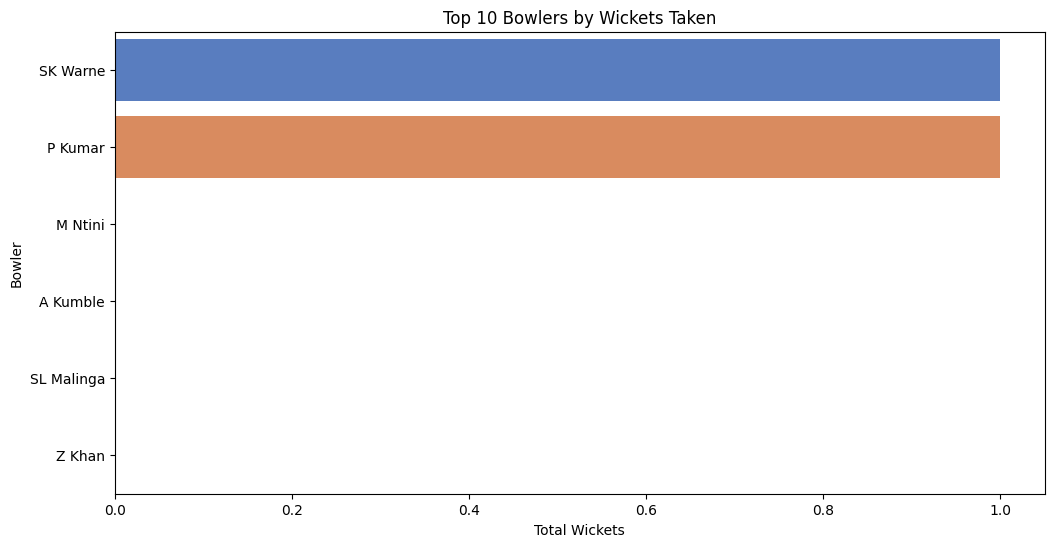

In [14]:
wickets_by_bowler = data.groupby(
    'bowler')['wickets'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=wickets_by_bowler.values,
            y=wickets_by_bowler.index, palette="muted")
plt.title('Top 10 Bowlers by Wickets Taken')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.show()

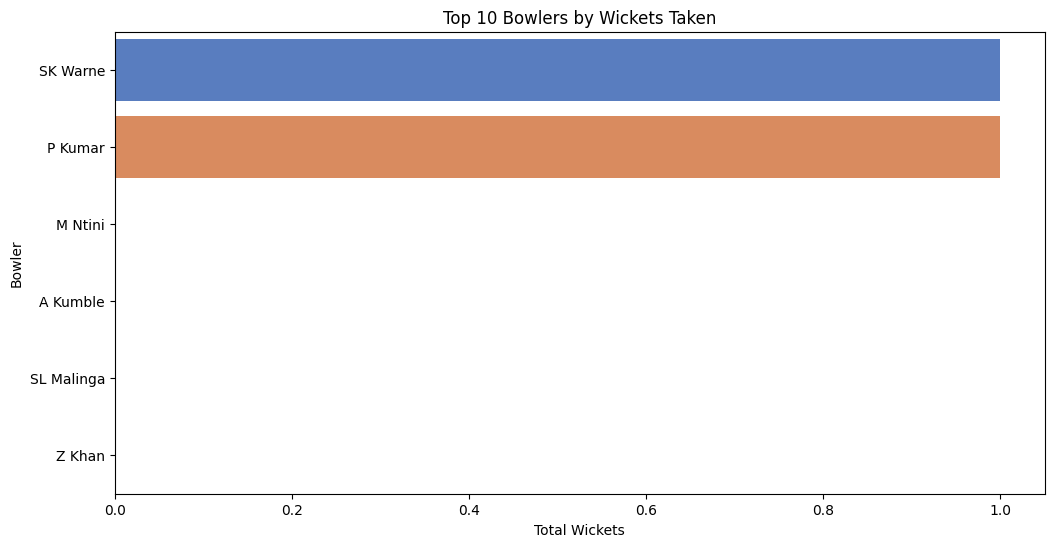

In [15]:
wickets_by_bowler = data.groupby(
    'bowler')['wickets'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=wickets_by_bowler.values,
            y=wickets_by_bowler.index, palette="muted")
plt.title('Top 10 Bowlers by Wickets Taken')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['bat_team', 'bowl_team', 'venue', "batsman", "bowler"]

data_encoded = data.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

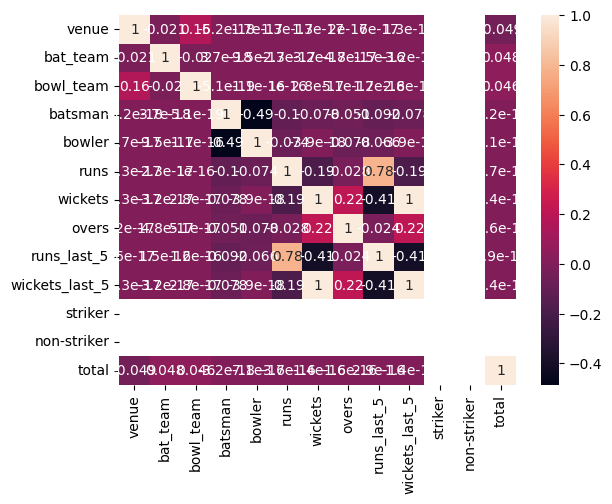

In [18]:
data_corr = data_encoded.drop(columns=["date", "mid"], axis=1)
sns.heatmap(data_corr.corr(), annot=True)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
feature_cols = ['bat_team', 'bowl_team', 'venue', 'runs',
                'wickets', 'overs', 'striker', 'batsman', 'bowler']

X = data_encoded[feature_cols]
y = data_encoded['total']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
model = keras.Sequential([
    keras.layers.Input( shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(216, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

huber_loss = tf.keras.losses.Huber(delta=1.0)  # You can adjust the 'delta' parameter as needed
model.compile(optimizer='adam', loss=huber_loss)

In [22]:
model.fit(X_train_scaled, y_train, epochs=10, batch_size=64, validation_data=(X_test_scaled, y_test))

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 180.6735 - val_loss: 177.8562
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 178.3030 - val_loss: 174.5840
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 174.0814 - val_loss: 168.6222
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 166.5309 - val_loss: 158.2485
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 153.6897 - val_loss: 141.2032
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 133.2533 - val_loss: 114.7216
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 101.9565 - val_loss: 75.7443
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 59.2234 - val_loss: 32.8235
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 30.5627 - val_loss: 35.9079
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 35.7559 - val_loss: 32.9373


<Axes: >

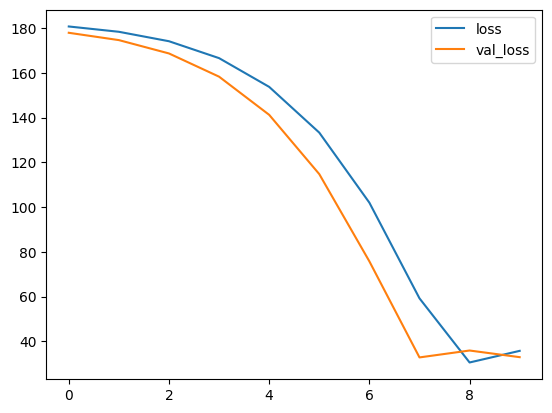

In [23]:
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
predictions = model.predict(X_test_scaled)

mean_absolute_error(y_test, predictions)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


33.43368148803711

In [25]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

venue = widgets.Dropdown(options=list(
    label_encoders['venue'].classes_), description='Select Venue:')
venue.style = {'description_width': 'initial'}

batting_team = widgets.Dropdown(options=list(
    label_encoders['bat_team'].classes_), description='Select Batting Team:')
batting_team.style = {'description_width': 'initial'}

bowling_team = widgets.Dropdown(options=list(
    label_encoders['bowl_team'].classes_), description='Select Bowling Team:')
bowling_team.style = {'description_width': 'initial'}

striker = widgets.Dropdown(options=list(
    label_encoders['batsman'].classes_), description='Select Striker:')
striker.style = {'description_width': 'initial'}

bowler = widgets.Dropdown(options=list(
    label_encoders['bowler'].classes_), description='Select Bowler:')
bowler.style = {'description_width': 'initial'}

runs = widgets.IntText(value=0, description='Runs:', style={
                       'description_width': 'initial'})
wickets = widgets.IntText(value=0, description='Wickets:', style={
                          'description_width': 'initial'})
overs = widgets.FloatText(value=0.0, description='Overs:', style={
                          'description_width': 'initial'})
striker_ind = widgets.IntText(value=0, description='Striker:', style={
                              'description_width': 'initial'})  # Assuming 0 or 1
predict_button = widgets.Button(description="Predict Score")

output = widgets.Output()


def predict_score(b):
    with output:
        clear_output()  # Clear previous output

        encoded_venue = label_encoders['venue'].transform([venue.value])[0]
        encoded_batting_team = label_encoders['bat_team'].transform(
            [batting_team.value])[0]
        encoded_bowling_team = label_encoders['bowl_team'].transform(
            [bowling_team.value])[0]
        encoded_striker = label_encoders['batsman'].transform([striker.value])[
            0]
        encoded_bowler = label_encoders['bowler'].transform([bowler.value])[0]

        input_features = [
            encoded_batting_team,
            encoded_bowling_team,
            encoded_venue,
            runs.value,
            wickets.value,
            overs.value,
            striker_ind.value,
            encoded_striker,
            encoded_bowler
        ]

        input_array = np.array(input_features).reshape(1, -1)
        input_array = scaler.transform(input_array)
        predicted_score = model.predict(input_array)

        print(f"Predicted Total Runs: {int(predicted_score[0])}")


predict_button.on_click(predict_score)

display(venue, batting_team, bowling_team, striker, bowler,
        runs, wickets, overs,
        striker_ind,
        predict_button, output)

Dropdown(description='Select Venue:', options=('Eden Gardens', 'Feroz Shah Kotla', 'M Chinnaswamy Stadium', 'M…

Dropdown(description='Select Batting Team:', options=('Chennai Super Kings', 'Delhi Daredevils', 'Kolkata Knig…

Dropdown(description='Select Bowling Team:', options=('Chennai Super Kings', 'Delhi Daredevils', 'Kolkata Knig…

Dropdown(description='Select Striker:', options=('BB McCullum', 'MS Dhoni', 'SC Ganguly', 'SR Tendulkar', 'V S…

Dropdown(description='Select Bowler:', options=('A Kumble', 'M Ntini', 'P Kumar', 'SK Warne', 'SL Malinga', 'Z…

...

IntText(value=0, description='Wickets:', style=DescriptionStyle(description_width='initial'))

FloatText(value=0.0, description='Overs:', style=DescriptionStyle(description_width='initial'))

IntText(value=0, description='Striker:', style=DescriptionStyle(description_width='initial'))

Button(description='Predict Score', style=ButtonStyle())

Output()